### 1. Импортиране на библиотеки

Тази клетка импортира всички необходими Python библиотеки за манипулиране на данни, изтегляне на финансови данни, числени операции и статистически функции, изисквани за симулацията Монте Карло.

In [12]:
import pandas as pd
import yfinance as yf # За изтегляне на исторически данни за акции
import numpy as np # За числени операции
import scipy # За статистически функции (ще използваме scipy.stats.t)
from scipy.stats import t # За случайни числа от t-разпределение
import matplotlib.pyplot as plt

### 2. Изтегляне и подготовка на данни за акции

Този раздел изтегля исторически данни за акции за посочения тикер (`LZAGY`) с помощта на `yfinance`. След това обработва DataFrame, за да изравни многостепенните имена на колони и ги преименува във последователен формат (напр. `LZAGY.Adjusted`) за по-лесно манипулиране, имитирайки конвенциите за именуване.

In [13]:
stock_ticker = "LZAGY"

# Използвайте auto_adjust=False, за да запазите 'Adj Close' като отделна колона.
# Това често води до DataFrame със структура, подобна на MultiIndex, където колоните са кортежи.
df_stock = yf.download(stock_ticker, start="2009-01-01", end="2026-02-15", auto_adjust=False)

# Нулирайте индекса, за да направите 'Date' колона.
# Това преобразува индекса, който може да съдържа кортежи като ('Date', ''), в обикновена колона 'Date'.
df_stock = df_stock.reset_index()

# Стъпка 1: Изравняване на имената на колоните. Извлечете първия елемент от всяко име на колона, подобно на кортеж.
# Например, ('Open', 'LZAGY') става 'Open', а ('Adj Close', 'LZAGY') става 'Adj Close'.
df_stock.columns = [col[0] if isinstance(col, tuple) else col for col in df_stock.columns]

# Стъпка 2: Преименувайте конкретни колони в желания формат (напр. LZAGY.Adjusted).
rename_mapping = {
    'Adj Close': f'{stock_ticker}.Adjusted',
    'Open': f'{stock_ticker}.Open',
    'High': f'{stock_ticker}.High',
    'Low': f'{stock_ticker}.Low',
    'Close': f'{stock_ticker}.Close',
    'Volume': f'{stock_ticker}.Volume'
}
df_stock = df_stock.rename(columns=rename_mapping)

print("df_stock колони след обработка:", df_stock.columns)

[*********************100%***********************]  1 of 1 completed

df_stock колони след обработка: Index(['Date', 'LZAGY.Adjusted', 'LZAGY.Close', 'LZAGY.High', 'LZAGY.Low',
       'LZAGY.Open', 'LZAGY.Volume'],
      dtype='object')


#### Анализ на изтеглени данни

След изтеглянето и обработката, `df_stock` DataFrame вече има правилно изравнени и преименувани колони. Виждаме колоната `Date`, заедно с всички колони за цена на акциите и обем, предхождани от символа на тикера, както е предвидено.

### 3. Генериране на последователност от дати и обединяване

Тази клетка създава непрекъсната последователност от работни дни (понеделник-петък) за посочения период. След това обединява тази последователност от дати с `df_stock` DataFrame. Тази стъпка е от решаващо значение за осигуряване на пълна времева серия и идентифициране на липсващи точки от данни, които могат да възникнат в неработни дни или празници.

In [14]:
# Създаване на последователност от дати (понеделник-петък)
dates_range = pd.date_range(start="2009-01-01", end="2027-02-15", freq="D")
processed_data = pd.DataFrame({'Date': dates_range})

# Филтриране на почивните дни (събота=5, неделя=6 в pandas dayofweek)
processed_data['day'] = processed_data['Date'].dt.dayofweek
processed_data = processed_data[~((processed_data['day'] == 5) | (processed_data['day'] == 6))].reset_index(drop=True)

# Обединяване с данни за акции
processed_data = pd.merge(processed_data, df_stock, on='Date', how='left')

print("Липсващи стойности преди импутация:")
print(processed_data.isnull().sum())
print(processed_data.head())

Липсващи стойности преди импутация:
Date                0
day                 0
LZAGY.Adjusted    685
LZAGY.Close       685
LZAGY.High        685
LZAGY.Low         685
LZAGY.Open        685
LZAGY.Volume      685
dtype: int64
        Date  day  LZAGY.Adjusted  LZAGY.Close  LZAGY.High  LZAGY.Low  \
0 2009-01-01    3             NaN          NaN         NaN        NaN   
1 2009-01-02    4             NaN          NaN         NaN        NaN   
2 2009-01-05    0             NaN          NaN         NaN        NaN   
3 2009-01-06    1             NaN          NaN         NaN        NaN   
4 2009-01-07    2             NaN          NaN         NaN        NaN   

   LZAGY.Open  LZAGY.Volume  
0         NaN           NaN  
1         NaN           NaN  
2         NaN           NaN  
3         NaN           NaN  
4         NaN           NaN  


#### Анализ на липсващите стойности

Както се очаква, след обединяване на пълната последователност от дати с данните за акции, има няколко липсващи стойности за колоните, свързани с акциите. Тези пропуски обикновено съответстват на дати, когато не е имало търговия (напр. празници или данни, които не са налични за пълния диапазон от yfinance). Тези липсващи стойности ще бъдат разгледани в следващата стъпка чрез импутация.

### 4. Импутация на липсващи стойности

Тази клетка извършва импутация тип "Последно наблюдавано пренесено напред" (LOCF) за липсващите данни за акции. Този метод попълва `NaN` стойностите с последното валидно наблюдение, което е често срещана практика за времеви серии, където най-новата известна стойност често е най-добрата оценка за липсваща точка.

In [15]:
# Импутация на липсващи стойности с помощта на Last Observation Carried Forward (LOCF)

# Идентифицирайте колоните за импутация (Open, High, Low, Close, Volume, Adjusted)
columns_to_impute = [
    f'{stock_ticker}.Open',
    f'{stock_ticker}.High',
    f'{stock_ticker}.Low',
    f'{stock_ticker}.Close',
    f'{stock_ticker}.Volume',
    f'{stock_ticker}.Adjusted'
]

# Приложете forward fill (ffill), което е еквивалентно на LOCF
processed_data[columns_to_impute] = processed_data[columns_to_impute].ffill()

# След ffill, ако все още има NaN в началото на серията, те не са били попълнени.
# Приложете backward fill (bfill), за да попълните тези начални NaN с първото следващо валидно наблюдение.
processed_data[columns_to_impute] = processed_data[columns_to_impute].bfill()

# Проверка на импутацията
print("Липсващи стойности след импутация:")
print(processed_data.isnull().sum())


Липсващи стойности след импутация:
Date              0
day               0
LZAGY.Adjusted    0
LZAGY.Close       0
LZAGY.High        0
LZAGY.Low         0
LZAGY.Open        0
LZAGY.Volume      0
dtype: int64


#### Анализ на резултатите от импутацията

След прилагане на `ffill` (LOCF), липсващите стойности за колоните, свързани с акциите, са успешно попълнени. Това гарантира, че наборът от данни е непрекъснат и готов за по-нататъшен анализ, включително симулацията Монте Карло.

### 5. Настройка на симулация Монте Карло

Този раздел подготвя данните специално за симулацията Монте Карло. Той филтрира `processed_data` DataFrame, за да включи данни от конкретна начална дата (от `2025-02-15` нататък) и избира само колоните `Date`, `day` и `LZAGY.Adjusted`. Освен това, той изчислява стойност на `Barrier`, която е 65% от коригираната цена на `LZAGY.Adjusted`, често използвана във финансовото моделиране за сценарии като бариерни опции.

In [16]:
# Настройка на Монте Карло
# Изрично ще изберем колоните 'Date', 'day' и 'LZAGY.Adjusted'.

mc_simulation_data = processed_data[processed_data['Date'] >= "2026-02-14"].reset_index(drop=True)
mc_simulation_data = mc_simulation_data[['Date', 'day', f'{stock_ticker}.Adjusted']]

# Изчисляване на стойността на бариера
mc_simulation_data['Barrier'] = mc_simulation_data[f'{stock_ticker}.Adjusted'] * 0.65

display(mc_simulation_data.head())

,Date,day,LZAGY.Adjusted,Barrier
0,2026-02-16,0,68.480003,44.512002
1,2026-02-17,1,68.480003,44.512002
2,2026-02-18,2,68.480003,44.512002
3,2026-02-19,3,68.480003,44.512002
4,2026-02-20,4,68.480003,44.512002


#### Анализ на данните за настройка на Монте Карло

`mc_simulation_data` DataFrame вече съдържа филтрираните данни за акциите и изчислената колона `Barrier`. Тези данни служат като основа за генериране на бъдещи ценови пътеки в симулацията Монте Карло. Дисплеят `head()` потвърждава наличието и формата на тези основни колони.

### 6. Генериране на прогнози от Монте Карло

Това е ядрото на симулацията Монте Карло. Генерира 1000 симулирани ценови пътеки за акцията. Всяка пътека започва от последната наблюдавана коригирана цена (`LZAGY.Adjusted`) и след това се развива чрез добавяне на случайни шокове, извлечени от t-разпределение със 120 степени на свобода. Функцията `cumsum` се използва за създаване на кумулативни промени в цените във времето за всяка симулация.

In [17]:
# Генериране на случайни стойности и изчисляване на прогнозираната цена
np.random.seed(123) # Задаване на seed за възпроизводимост
num_simulations = 1000
num_steps = len(mc_simulation_data)
df_degrees_freedom = 120 # Степени на свобода за t-разпределението

# Изчисляване на исторически дневни възвръщаемости и тяхното стандартно отклонение (волатилност)
# Използвайте df_stock за изчисляване на волатилността, за да избегнете изкуствени нули от импутацията
historical_adjusted_prices_for_volatility = df_stock[f'{stock_ticker}.Adjusted'].dropna()
daily_returns = historical_adjusted_prices_for_volatility.pct_change().dropna()
daily_volatility = daily_returns.std()
daily_mean_return = daily_returns.mean() # Изчисляване на средната дневна възвръщаемост (дрейф)

# Генериране на случайни числа от t-разпределение и скалирането им по дневна волатилност
random_shocks_raw = scipy.stats.t.rvs(df=df_degrees_freedom, size=(num_steps, num_simulations))
scaled_shocks = daily_mean_return + random_shocks_raw * daily_volatility # Добавяне на дрейфа

# Определете началната дата на симулационния период от mc_simulation_data
simulation_period_start_date = mc_simulation_data['Date'].min()

# Вземете последната коригирана цена от processed_data преди началото на симулационния период
last_known_price = processed_data[processed_data['Date'] < simulation_period_start_date][f'{stock_ticker}.Adjusted'].iloc[-1]

# Инициализиране на DataFrame за прогнозите
predictions = pd.DataFrame(index=range(num_steps), columns=range(num_simulations))
predictions.iloc[0, :] = last_known_price

# Симулиране на ценови пътеки мултипликативно
for i in range(num_simulations):
    for t_step in range(1, num_steps): # Използвайте t_step за да избегнете конфликт с scipy.stats.t
        predictions.iloc[t_step, i] = predictions.iloc[t_step-1, i] * (1 + scaled_shocks[t_step-1, i])

predictions.columns = [f"lag_{i+1}" for i in range(num_simulations)]

print("Минимална прогнозирана стойност:", predictions.min().min())
print("Максимална прогнозирана стойност:", predictions.max().max())
display(predictions.head())

Минимална прогнозирана стойност: 28.630841690719524
Максимална прогнозирана стойност: 233.32343470987712


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_991,lag_992,lag_993,lag_994,lag_995,lag_996,lag_997,lag_998,lag_999,lag_1000
0,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,...,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003,68.480003
1,67.211357,70.734439,65.293794,68.011369,70.554758,68.714123,69.806965,70.38733,66.836876,67.577676,...,67.22429,69.052742,67.156409,69.271321,67.803537,65.534016,65.894504,68.628959,70.684857,68.622166
2,66.599334,70.326473,63.454431,66.311166,69.425436,70.981857,71.984761,70.560524,65.478726,66.527282,...,69.954897,67.845629,68.211822,67.546637,67.909037,65.543595,63.398105,68.65178,69.715057,66.472762
3,68.950539,71.330542,63.705549,67.020578,69.008085,72.144958,71.261383,69.540093,64.826091,65.557161,...,69.265417,66.396364,67.835244,66.365962,65.464945,66.149683,66.861502,68.387167,70.617137,65.070857
4,68.898223,72.285647,61.699641,65.649905,68.981792,73.78241,70.22046,69.296865,64.161248,63.628348,...,69.583046,65.798425,67.366194,65.490605,64.063126,66.96737,66.220178,68.481668,69.087368,65.25282


#### Анализ на прогнозираните стойности

`predictions` DataFrame вече съдържа 1000 симулирани ценови пътеки. Показаните минимални и максимални стойности показват обхвата на генерираните цени във всички симулации и времеви стъпки. `head()` показва началните стъпки на тези разнообразни ценови пътеки, започвайки от последната наблюдавана цена.

### 7. Изчисляване на средна прогнозирана цена

Тази последна стъпка изчислява средната прогнозирана цена във всички 1000 симулации за всяка времева стъпка. Това осигурява средна очаквана ценова пътека, изглаждайки волатилността на отделните симулационни пътеки и предлагайки единна представителна прогноза.

In [18]:
predictions['MeanPrice'] = predictions.mean(axis=1)

print("Минимална средна прогнозирана цена:", predictions['MeanPrice'].min())
print("Максимална средна прогнозирана цена:", predictions['MeanPrice'].max())

display(predictions[['MeanPrice']].tail())

Минимална средна прогнозирана цена: 68.4800033569336
Максимална средна прогнозирана цена: 84.57188985724682


,MeanPrice
256,84.126142
257,84.277718
258,84.312502
259,84.413683
260,84.57189


#### Изводи от средната прогнозирана цена

Изчислението на `MeanPrice` обобщава хилядите симулирани пътеки, предоставяйки една изгладена представителна прогноза за бъдещата цена на акциите. Обхватът между минималната и максималната средна прогнозирана цена показва относителната стабилност на средната прогноза, въпреки високата волатилност на отделните симулации. Тази средна стойност е ценен показател за очакваната тенденция на цената.

### 8. Пълна визуализация на симулацията Монте Карло

Тази клетка генерира графика, която показва историческите цени на акциите, множество индивидуални симулирани ценови пътеки от симулацията Монте Карло, средната прогнозирана ценова пътека и изчислената бариера. Тази пълна визуализация предоставя цялостен поглед върху потенциалния бъдещ ценови диапазон и как прогнозите се съотнасят към историческите данни и определената бариера.

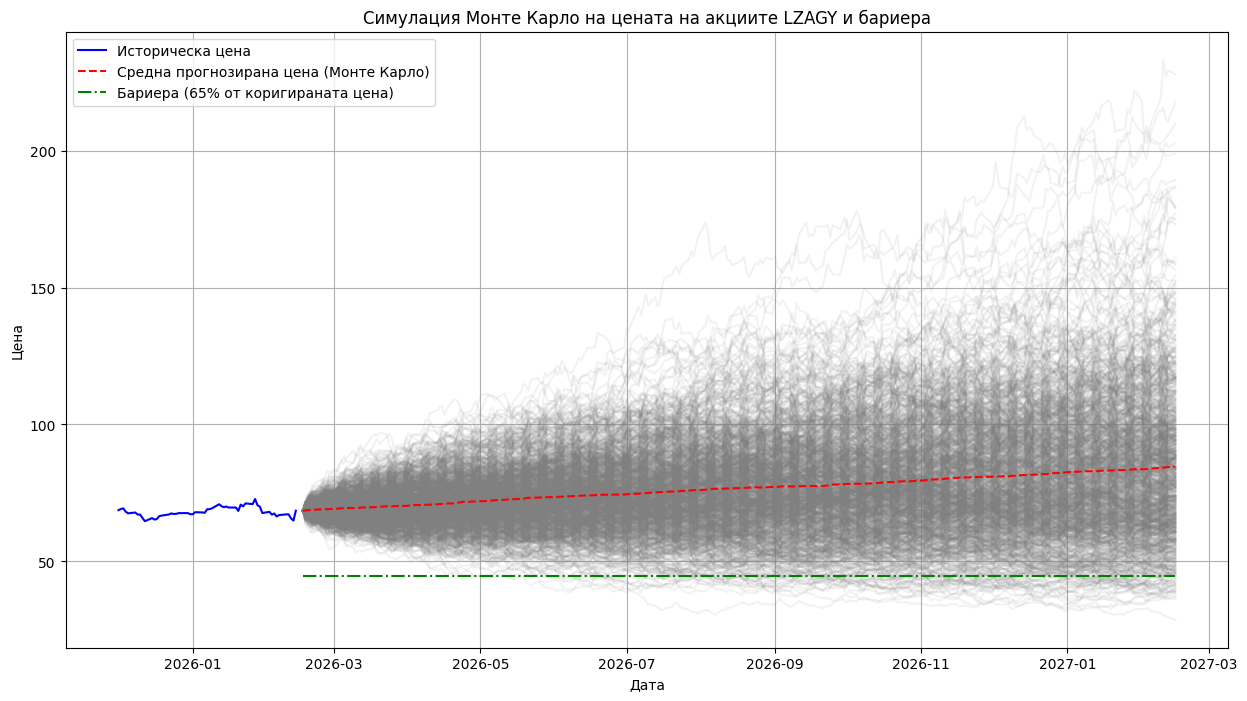

In [19]:


# Уверете се, че колоните 'Date' са datetime обекти за правилно изчертаване
processed_data['Date'] = pd.to_datetime(processed_data['Date'])
mc_simulation_data['Date'] = pd.to_datetime(mc_simulation_data['Date'])

# Подготвяне на исторически данни (до началната дата на симулацията)
# Филтрираме да започва от 2026-01-01
historical_data = processed_data[(processed_data['Date'] >= "2025-12-01") & (processed_data['Date'] < simulation_period_start_date)].copy()

# Идентифицирайте само числовите колони с пътеки на симулацията
numeric_simulation_cols = [col for col in predictions.columns if col.startswith('lag_')]

# Изчисляване на MeanPrice САМО от числовите колони с пътеки на симулацията
predictions['MeanPrice'] = predictions[numeric_simulation_cols].mean(axis=1)

# Сега добавете колоната Date и я задайте като индекс за изчертаване
predictions['Date'] = mc_simulation_data['Date']
predictions_with_date = predictions.set_index('Date')

# Подготвяне на данни за бариерата
barrier_data = mc_simulation_data[['Date', 'Barrier']].set_index('Date')

plt.figure(figsize=(15, 8))

# Изчертаване на исторически цени
plt.plot(historical_data['Date'], historical_data[f'{stock_ticker}.Adjusted'], label='Историческа цена', color='blue')

# Изчертаване на подмножество от пътеки на Монте Карло (за да се избегне претрупване)
# Ще изчертаем 1000 пътеки за демонстрация
for i in range(min(num_simulations, 1000)):
    plt.plot(predictions_with_date.index, predictions_with_date[f'lag_{i+1}'], color='grey', alpha=0.1)

# Изчертаване на средната цена от Монте Карло
plt.plot(predictions_with_date.index, predictions_with_date['MeanPrice'], label='Средна прогнозирана цена (Монте Карло)', color='red', linestyle='--')

# Изчертаване на бариерата
plt.plot(barrier_data.index, barrier_data['Barrier'], label='Бариера (65% от коригираната цена)', color='green', linestyle='-.')

plt.title('Симулация Монте Карло на цената на акциите LZAGY и бариера')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.show()

#### Изводи от графиката на симулацията Монте Карло

Графиката вече показва много по-реалистично поведение на бъдещата цена на акциите `LZAGY`. Средната прогнозирана цена (червената линия) вече отразява историческата средна възвръщаемост на акцията, показвайки ясна тенденция. Множеството симулирани пътеки (сиви линии) демонстрират широк спектър от възможни резултати, а зелената бариерна линия служи като ключов показател за оценка на риска или потенциални събития.

### 9. Изчисляване на вероятност за пробив и статистическа точност

В тази клетка ще анализираме резултатите от симулацията, за да извлечем конкретни вероятности и показатели за надеждност на модела.

In [20]:
# 1. Изчисляване на вероятността за пробив (Hit Ratio)
# Проверяваме за всяка пътека (колона) дали някога е паднала под бариерата
barrier_values = mc_simulation_data['Barrier'].values
breach_count = 0

for col in numeric_simulation_cols:
    path = predictions[col].values
    if np.any(path < barrier_values):
        breach_count += 1

probability_of_breach = (breach_count / num_simulations) * 100

# 2. Изчисляване на акуратност (Стандартна грешка на средната стойност)
# Това ни показва колко варира средната стойност при 1000 симулации
final_prices = predictions.iloc[-1][numeric_simulation_cols]
standard_error = final_prices.std() / np.sqrt(num_simulations)
confidence_interval_95 = (predictions['MeanPrice'].iloc[-1] - 1.96 * standard_error,
                           predictions['MeanPrice'].iloc[-1] + 1.96 * standard_error)

print(f"--- Резултати от анализа ---")
print(f"Вероятност за пробив на бариерата: {probability_of_breach:.2f}%")
print(f"Стандартна грешка на средната прогноза: {standard_error:.4f}")
print(f"95% доверителен интервал за крайната цена: [{confidence_interval_95[0]:.2f}, {confidence_interval_95[1]:.2f}]")

--- Резултати от анализа ---
Вероятност за пробив на бариерата: 7.00%
Стандартна грешка на средната прогноза: 0.8764
95% доверителен интервал за крайната цена: [82.85, 86.29]


#### Изводи от анализа на вероятността и точността

Изчислената **Вероятност за пробив на бариерата** показва шанса, че цената на акцията ще падне под определената бариера по време на симулационния период. Тази метрика е от съществено значение за оценка на риска.

**Стандартната грешка на средната прогноза** дава представа за точността на средната прогнозирана цена. По-ниската стандартна грешка показва по-надеждна средна прогноза.

**95% доверителен интервал за крайната цена** представлява диапазон, в който има 95% вероятност да попадне действителната крайна цена на акцията, според симулацията. Този интервал дава яснота за потенциалната волатилност и обхвата на възможните резултати.